In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.applications import ResNet50, Xception, EfficientNetV2S, VGG16
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import classification_report
import warnings
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, matthews_corrcoef, cohen_kappa_score
)
import seaborn as sns
warnings.filterwarnings("ignore")

## Load dataset
dataset contains pf header info

This dataset contains headers of 6978 binary executable 

In [2]:
df = pd.read_csv('Rpe_headers.csv')

In [3]:
# preview data
df.head()

,GR,0,1,2,3,4,5,6,7,8,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
1,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
2,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
3,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0
4,0,77,90,144,0,3,0,0,0,4,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# PE Header 1024
df.iloc[:, 1:]

,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
1,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
2,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
3,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
4,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6973,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
6974,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0
6975,77,90,144,0,3,0,0,0,4,0,...,141,125,180,86,141,117,212,219,64,106
6976,77,90,144,0,3,0,0,0,4,0,...,0,0,0,0,0,0,0,0,0,0


## Convert to colored and Split data

In [6]:
# Split the data into training and validation sets (70% for training, 20% for validation, 10% for test)
train_df, val_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(val_df, test_size=1/3, random_state=42)

# Convert the numerical columns to image
train_images = train_df.iloc[:, 1:].values.reshape(-1, 32, 32,1)
val_images = val_df.iloc[:, 1:].values.reshape(-1, 32, 32,1)
test_images = test_df.iloc[:, 1:].values.reshape(-1, 32, 32,1)

# Normalize the image values to [0, 1]
train_images = train_images / 255.0
val_images = val_images / 255.0
test_images = test_images / 255.0

# Convert the numerical columns to color images
train_images = np.repeat(train_images, 3, axis=3)
val_images = np.repeat(val_images, 3, axis=3)
test_images = np.repeat(test_images, 3, axis=3)

In [7]:
# Reshape each image in train_images to (256, 256, 3)
train_images = tf.image.resize(train_images, (256, 256))

# Reshape each image in val_images to (256, 256, 3)
val_images = tf.image.resize(val_images, (256, 256))

# Reshape each image in test_images to (256, 256, 3)
test_images = tf.image.resize(test_images, (256, 256))

## Build Resnet model for Goodware and randsomeware detection

In [8]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values
test_labels = test_df['GR'].values

In [9]:
# Define the ResNet model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [10]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [11]:
model.fit(train_images, train_labels, epochs=20, validation_data=(val_images, val_labels))

Epoch 1/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 648s 4s/step - accuracy: 0.6223 - loss: 1.5058 - val_accuracy: 0.8023 - val_loss: 0.4617
Epoch 2/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 580s 4s/step - accuracy: 0.7390 - loss: 0.5243 - val_accuracy: 0.7765 - val_loss: 0.4715
Epoch 3/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 538s 4s/step - accuracy: 0.7905 - loss: 0.4521 - val_accuracy: 0.5809 - val_loss: 0.7856
Epoch 4/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 435s 3s/step - accuracy: 0.7537 - loss: 0.5266 - val_accuracy: 0.8188 - val_loss: 0.3976
Epoch 5/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 437s 3s/step - accuracy: 0.8041 - loss: 0.4392 - val_accuracy: 0.8223 - val_loss: 0.3852
Epoch 6/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 446s 3s/step - accuracy: 0.8358 - loss: 0.3812 - val_accuracy: 0.8546 - val_loss: 0.3592
Epoch 7/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 441s 3s/step - accuracy: 0.8110 - loss: 0.4170 - val_accuracy: 0.8460 - val_loss: 0.3598
Epoch 8/20
153/153 ━━━━━━━━━━━━━━━━━━━━ 437s 3s/step - accuracy: 0.8325 - loss: 0.3769 - val_accu

In [12]:
# Evaluate the model on the validation set
y_pred = model.predict(test_images)

22/22 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step


In [13]:
# Convert the predictions to labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype(int)

# Get the true labels
y_true = test_labels

# Print the classification report
print(classification_report(y_true, y_pred_labels,target_names=['Goodware','Ransomeware']))

              precision    recall  f1-score   support

    Goodware       0.83      0.91      0.87       337
 Ransomeware       0.91      0.83      0.87       361

    accuracy                           0.87       698
   macro avg       0.87      0.87      0.87       698
weighted avg       0.87      0.87      0.87       698



In [14]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

# Precision
precision = precision_score(y_true, y_pred_labels)

# Recall
recall = recall_score(y_true, y_pred_labels)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# FN rate (False Negative Rate)
fn_rate = fn / (fn + tp)

# FP rate (False Positive Rate)
fp_rate = fp / (fp + tn)

# F-measure
f_measure = f1_score(y_true, y_pred_labels)

# Error rate
error_rate = 1 - accuracy

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred_labels)

# Kappa
kappa = cohen_kappa_score(y_true, y_pred_labels)

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_pred)

# Print the classification report
print(classification_report(y_true, y_pred_labels, target_names=['Goodware', 'Ransomeware']))

# Print all the metrics
print(f"Confusion Matrix: \n{cm}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"FN Rate: {fn_rate:.4f}")
print(f"FP Rate: {fp_rate:.4f}")
print(f"F-measure: {f_measure:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

              precision    recall  f1-score   support

    Goodware       0.83      0.91      0.87       337
 Ransomeware       0.91      0.83      0.87       361

    accuracy                           0.87       698
   macro avg       0.87      0.87      0.87       698
weighted avg       0.87      0.87      0.87       698

Confusion Matrix: 
[[308  29]
 [ 61 300]]
Precision: 0.9119
Recall: 0.8310
Accuracy: 0.8711
FN Rate: 0.1690
FP Rate: 0.0861
F-measure: 0.8696
Error Rate: 0.1289
MCC: 0.7458
Kappa: 0.7426
AUC-ROC: 0.9451


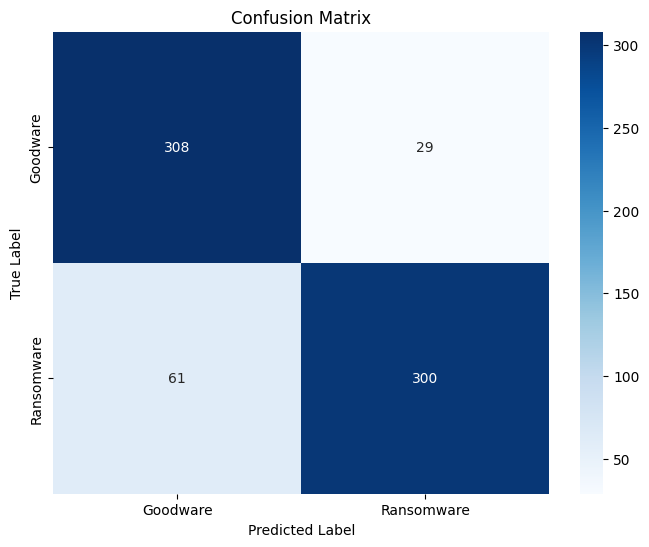

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Ransomware'], yticklabels=['Goodware', 'Ransomware'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [16]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:4]]

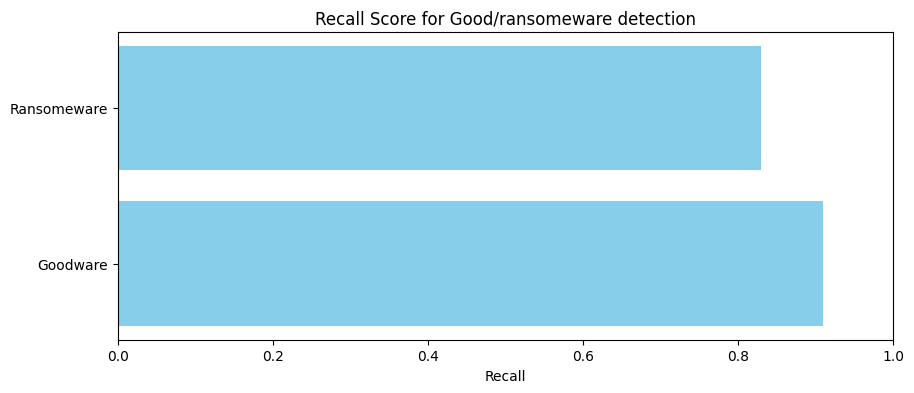

In [17]:
plt.figure(figsize=(10, 4))
plt.barh(['Goodware','Ransomeware'], recall_scores, color='skyblue')
plt.xlabel('Recall')
plt.title('Recall Score for Good/ransomeware detection')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()

## Build Xception model for Goodware/Ransomeware detection

In [23]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values
test_labels = test_df['GR'].values

In [24]:
# Define the ResNet model
base_model = Xception(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model_xception = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [25]:
# Compile the model
model_xception.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [26]:
# train model
model_xception.fit(train_images, train_labels, epochs=15, validation_data=(val_images, val_labels))

Epoch 1/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 680s 4s/step - accuracy: 0.7456 - loss: 1.2220 - val_accuracy: 0.8961 - val_loss: 0.2534
Epoch 2/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 664s 4s/step - accuracy: 0.8823 - loss: 0.2662 - val_accuracy: 0.9183 - val_loss: 0.2134
Epoch 3/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 684s 4s/step - accuracy: 0.9170 - loss: 0.1975 - val_accuracy: 0.9262 - val_loss: 0.2063
Epoch 4/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 568s 4s/step - accuracy: 0.9432 - loss: 0.1492 - val_accuracy: 0.9391 - val_loss: 0.1795
Epoch 5/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 550s 4s/step - accuracy: 0.9337 - loss: 0.1717 - val_accuracy: 0.9370 - val_loss: 0.1923
Epoch 6/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 529s 3s/step - accuracy: 0.9552 - loss: 0.1233 - val_accuracy: 0.9427 - val_loss: 0.1674
Epoch 7/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 557s 4s/step - accuracy: 0.9573 - loss: 0.1091 - val_accuracy: 0.9420 - val_loss: 0.1625
Epoch 8/15
153/153 ━━━━━━━━━━━━━━━━━━━━ 537s 4s/step - accuracy: 0.9762 - loss: 0.0697 - val_accu

In [27]:
# Evaluate the model on the validation set
y_pred = model_xception.predict(test_images)

22/22 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step


In [28]:
# Convert the predictions to labels (0 or 1)
y_pred_labels = (y_pred > 0.5).astype(int)

# Get the true labels
y_true = test_labels

# Print the classification report
print(classification_report(y_true, y_pred_labels,target_names=['Goodware','Ransomeware']))

              precision    recall  f1-score   support

    Goodware       0.90      0.96      0.93       337
 Ransomeware       0.96      0.90      0.93       361

    accuracy                           0.93       698
   macro avg       0.93      0.93      0.93       698
weighted avg       0.93      0.93      0.93       698



In [29]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_labels)
tn, fp, fn, tp = cm.ravel()

# Precision
precision = precision_score(y_true, y_pred_labels)

# Recall
recall = recall_score(y_true, y_pred_labels)

# Accuracy
accuracy = accuracy_score(y_true, y_pred_labels)

# FN rate (False Negative Rate)
fn_rate = fn / (fn + tp)

# FP rate (False Positive Rate)
fp_rate = fp / (fp + tn)

# F-measure
f_measure = f1_score(y_true, y_pred_labels)

# Error rate
error_rate = 1 - accuracy

# Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(y_true, y_pred_labels)

# Kappa
kappa = cohen_kappa_score(y_true, y_pred_labels)

# AUC-ROC
auc_roc = roc_auc_score(y_true, y_pred)

# Print the classification report
print(classification_report(y_true, y_pred_labels, target_names=['Goodware', 'Ransomeware']))

# Print all the metrics
print(f"Confusion Matrix: \n{cm}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"FN Rate: {fn_rate:.4f}")
print(f"FP Rate: {fp_rate:.4f}")
print(f"F-measure: {f_measure:.4f}")
print(f"Error Rate: {error_rate:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"Kappa: {kappa:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

              precision    recall  f1-score   support

    Goodware       0.90      0.96      0.93       337
 Ransomeware       0.96      0.90      0.93       361

    accuracy                           0.93       698
   macro avg       0.93      0.93      0.93       698
weighted avg       0.93      0.93      0.93       698

Confusion Matrix: 
[[322  15]
 [ 36 325]]
Precision: 0.9559
Recall: 0.9003
Accuracy: 0.9269
FN Rate: 0.0997
FP Rate: 0.0445
F-measure: 0.9272
Error Rate: 0.0731
MCC: 0.8555
Kappa: 0.8540
AUC-ROC: 0.9759


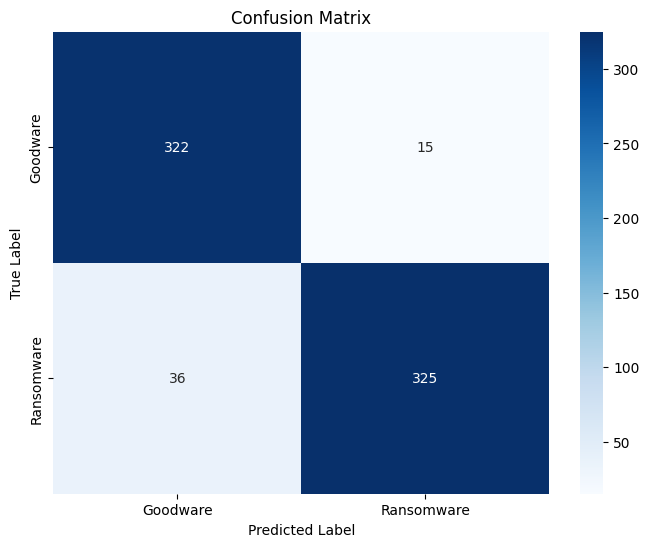

In [30]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Goodware', 'Ransomware'], yticklabels=['Goodware', 'Ransomware'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

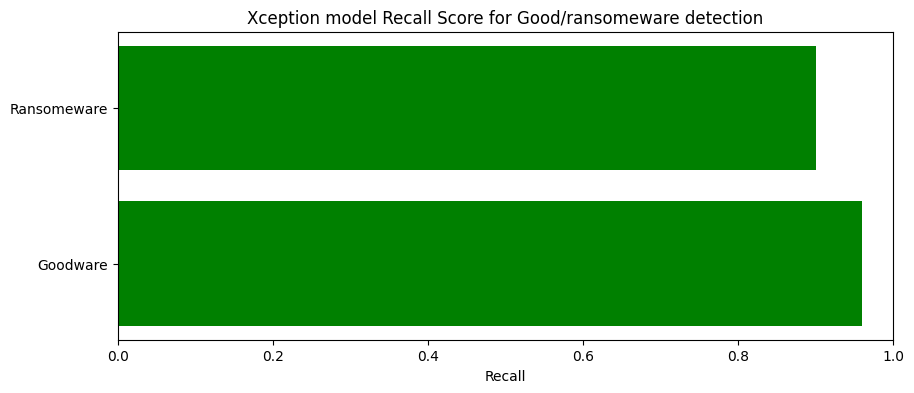

In [31]:
lines = classification_report(y_true, y_pred_labels).split('\n')
recall_scores = [float(line.split()[2]) for line in lines[2:4]]

plt.figure(figsize=(10, 4))
plt.barh(['Goodware','Ransomeware'], recall_scores, color='green')
plt.xlabel('Recall')
plt.title('Xception model Recall Score for Good/ransomeware detection')
plt.xlim(0, 1)  # Set x-axis limit to ensure consistency
plt.show()

## Build VGG16 model for Goodware/Ransomeware detection

In [32]:
# get target label
train_labels = train_df['GR'].values
val_labels = val_df['GR'].values
test_labels = test_df['GR'].values

In [34]:
# Define the ResNet model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# Flatten the output from the base model
x = Flatten()(base_model.output)

# Add a dense layer with 26 units for classification
x = Dense(256, activation='relu')(x)
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
x = Dense(1, activation='sigmoid')(x) #Dense(2, activation='softmax')(x)

# Define the model
model_VGG = tf.keras.Model(inputs=base_model.input, outputs=x)

# Freeze some layers
for layer in base_model.layers:
    layer.trainable = False

In [35]:
# Compile the model
model_VGG.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])